<a href="https://colab.research.google.com/github/FreJa90/python_for_ds_tasks/blob/main/HW_11_1_%D0%92%D1%96%D0%B7%D1%83%D0%B0%D0%BB%D1%96%D0%B7%D0%B0%D1%86%D1%96%D1%8F_%D0%B4%D0%B0%D0%BD%D0%B8%D1%85_%D0%B7_Pandas_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання: Візуалізація даних з Pandas

## Опис завдання
У цьому домашньому завданні ви працюватимете з датасетом про оренду велосипедів `yulu_rental.csv`. Датасет містить інформацію про кількість орендованих велосипедів залежно від погодних умов, сезону та інших факторів.
Набір даних взяти з Kaggle. Посилання на оригінальний [опис](https://www.kaggle.com/datasets/ranitsarkar01/yulu-bike-sharing-data?select=yulu_bike_sharing_dataset.csv).

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів



---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.


Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

## Підготовка даних


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Завантаження даних
df = pd.read_csv('/content/drive/MyDrive/Модуль 11. Візуалізація даних для аналізу з бібліотеками matplotlib, seaborn, plotly/data/yulu_rental.csv')

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# Перетворення datetime у правильний формат
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour

## Завдання 0: Перегляд даних
**Завдання:**
Перегляньте дані, їх розмір, та напишіть висновок:
- скільки даних в наборі
- який рівень деталізації мають ці дані, тобто за який період міститься дані в одному рядку даних ?

In [5]:
print(df.shape)
df.head()

(10886, 19)


,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,day,week,weekday_num,weekday,year,month,hour
datetime,,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011-01-01,1,52,5,Saturday,2011,1,0
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011-01-01,1,52,5,Saturday,2011,1,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011-01-01,1,52,5,Saturday,2011,1,2
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,2011-01-01,1,52,5,Saturday,2011,1,3
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,2011-01-01,1,52,5,Saturday,2011,1,4


В наборі 19 колонок та 10886 рядків. Деталізація поденна.

In [6]:
import matplotlib
import seaborn
import plotly

print("matplotlib version:", matplotlib.__version__)
print("seaborn version:", seaborn.__version__)
print("plotly version:", plotly.__version__)

matplotlib version: 3.10.0
seaborn version: 0.13.2
plotly version: 5.24.1


## Завдання 1: Базовий лінійний графік

**Завдання:**
1. Згрупуйте дані про кількість орендованих велосипедів (`count`) поденно.
2. Побудуйте з методом `DataFrame.plot()` лінійний графік поденної кількості орендованих велосипедів (`count`) за весь період в даних.
3. Налаштуйте розмір графіка (12x6), додайте заголовок "Динаміка оренди велосипедів" та сітку.
4. Дайте відповіді на питання по цьому графіку. Якщо треба - проведіть додаткові програмні операції для відповідей.

**Питання для інтерпретації:**
1. Як гадаєте, чому графік має "заломи", чим це спричинено і як ви б могли прибрати заломи?
2. Які загальні тенденції ви бачите на графіку?
3. Чи помітні якісь сезонні коливання?
4. Чи є періоди з аномально високими або низькими значеннями і чому на ваш погляд можуть бути ці аномалії?


1.Заломи пов'язані з тим, що в деякі дні кількість є рівною 0(також можуть бути пропуски в данних)
2.Найпростіший шлях згладити заломи, на мою думку, це зробити групування потижневе чи помісячне.
3. загальна тенденція це збільшення кількості в 2012 порівняно з 2011, а також підвищений попит на оренду з квітня по жовтень.
4.Є періоди з анамалльно високими значеннями, як в кінці березня 2012, в червні та вереснію. Ну і анамально низкькі, наприклад в грудні 2011, зимові місяці також вирізняються низькою орендою. Причини в обох випадках можуть бути різними: погода, свята, промо акції, пропуски в данних(для низкьких показників), загальносвітові тинденції, якісб футбольні матчі, чи чергові кінці світу.

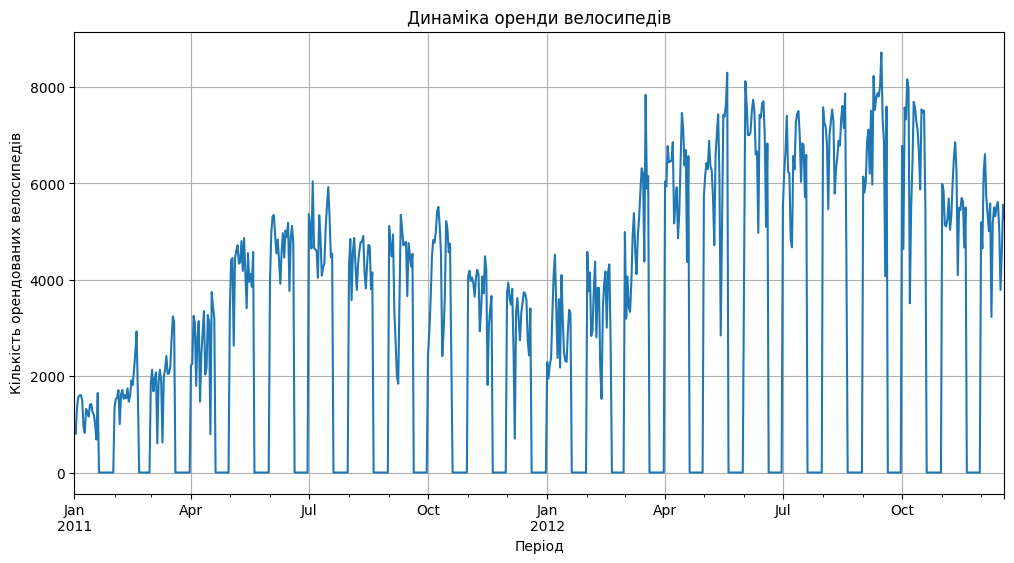

In [7]:
daily_rent = df['count'].resample('D').sum()
daily_rent.plot(
    kind='line',
    figsize=(12, 6),
    title='Динаміка оренди велосипедів',
    grid='True',
    xlabel='Період',
    ylabel='Кількість орендованих велосипедів',
)
plt.show()


## Завдання 2: Аналіз сезонності (Bar Plot)

**Завдання:**
Побудуйте вертикальну стовпчасту діаграму середньої кількості орендованих велосипедів за сезонами(кварталами). Додайте підписи осей і заголовок.

Просунуте доповнення:
1. Позначте квартали не числом, а назвою на візуалізації.
2. Додайте підписи над стовпцями зі значеннями в кожному стовпці.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В який квартал найбільша середня кількість оренди велосипедів?
2. Як ви можете пояснити таку сезонну закономірність?
3. У скільки разів відрізняється оренда між найпопулярнішим та найменш популярним кварталми?

1.Найбільша середня кількість оренди велоспедів у Липні-Вересні 2012.
2.Можу пояснити літніми канікулами, відпустками, напливом туристів з інших країн.
3.Оренда відрізняється майже в 4 рази.

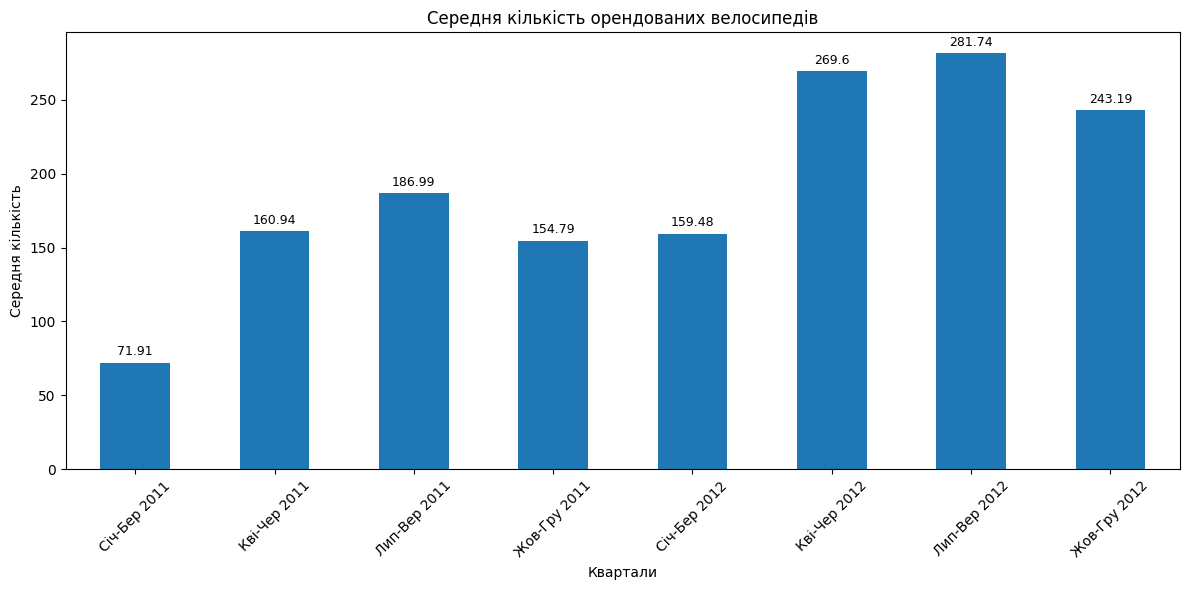

In [8]:
quarter_rent = df['count'].resample('QE').mean().round(2)

month_names = ['Січ', 'Лют', 'Бер', 'Кві', 'Тра', 'Чер', 'Лип', 'Сер', 'Вер', 'Жов', 'Лис', 'Гру']

labels = []
for d in quarter_rent.index:
    start_month = d.month - 2
    end_month = d.month
    labels.append(f'{month_names[start_month-1]}-{month_names[end_month-1]} {d.year}')

ax = quarter_rent.plot.bar(
    figsize=(12, 6),
    title='Середня кількість орендованих велосипедів',
    xlabel='Квартали',
    ylabel='Середня кількість'
)
ax.set_xticklabels(labels)

for i, value in enumerate(quarter_rent):
    ax.text(i, value + 3, str(value), ha='center', va='bottom', fontsize=9)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Завдання 3: Динаміка за місяцями (Line Plot)

**Завдання:**
Створіть лінійний графік середньої кількості оренд велосипедів на годину по місяцях (тобто групування в рамках місяця і беремо середню кількість оренд у цей місяць з кількох років). Використайте маркери-кружечки для точок, додайте сітку та пофарбуйте лінію у червоний колір.

Просунуте доповнення:
- додайте аби по осі ОХ поділки були чітко на кожен окремий місяць по одній. Тобто сумарно 12 поділок.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які місяці спостерігається пік та спад оренди?
2. Чи збігається ця закономірність з результатами з попереднього завдання?
3. Як може вплинути клімат на оренду велосипедів протягом року?


1.Пік в червні, спад в січні.
2. Спад з попереднім графіком збігається, а от пік був на попередньому графіку у липні-вересні найбільший, що не дивно так як це різна деталізація. Але різниця не велика.
3.Так, погода має вплив на оренду. Тому що ц
е велосипеди і погоді ззовні впливає на комфорт використання.

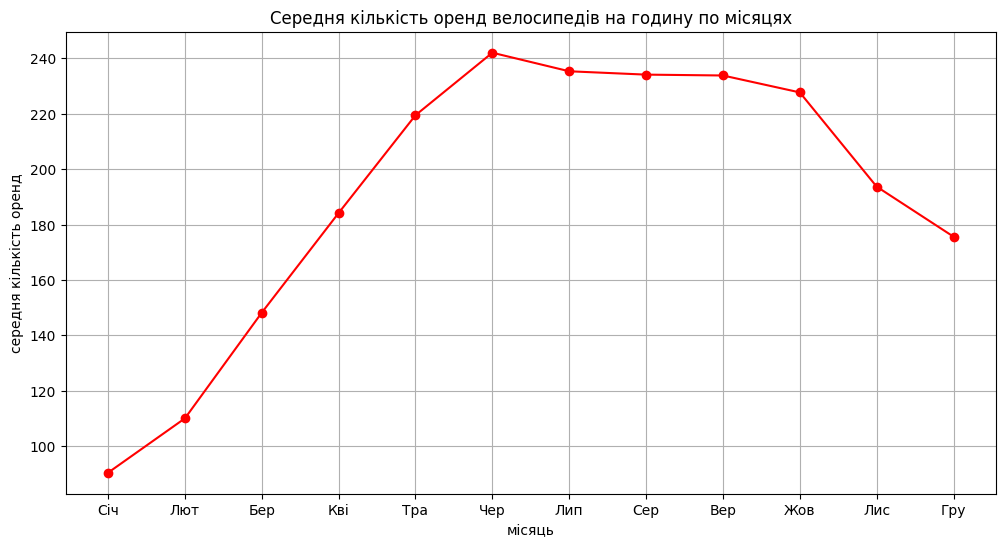

In [9]:
grouped_data = df.groupby(df['month'])['count'].mean().round(2)
month_names = ['Січ', 'Лют', 'Бер', 'Кві', 'Тра', 'Чер', 'Лип', 'Сер', 'Вер', 'Жов', 'Лис', 'Гру']
labels = [month_names[m-1] for m in grouped_data.index]

ax = grouped_data.plot(
    kind='line',
    figsize=(12, 6),
    color='red',
    marker='o',
    grid=True,
    title='Середня кількість оренд велосипедів на годину по місяцях',
    xlabel='місяць',
    ylabel='середня кількість оренд'
)
ax.set_xticks(grouped_data.index)
ax.set_xticklabels(labels)
plt.show()

## Завдання 4: Розподіл погодних умов (Pie Chart)

**Завдання:**
1. Побудуйте кругову діаграму з часткою записів за погодними умовами
2. Додайте підписи з відсотками та легенду з описами погоди (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ).
3. Визначте свої відмінні від стандартних кольори для відображення кожної категорії.
4. Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. Яка погода переважає в датасеті?
2. Чи є дні із сильним дощем? Яка їх частка?
3. Як ви думаєте, як погодні умови впливають на попит на оренду велосипедів?



1.   В датасеті переважає ясна погода
2.   Так, присутня мізерна частка з сильним дошем 0.01%
3.   Як я зазнчала раніше, погода дуже впливає на бажання пересуватись на велосипеді, так як сильний дощ і взагалі дощ робить досвід максимально некомфортним, і часами унеможливлює поїздку. Особливо якщо це прогулянка і поїздки для задоволення.





Очікуваний результат:

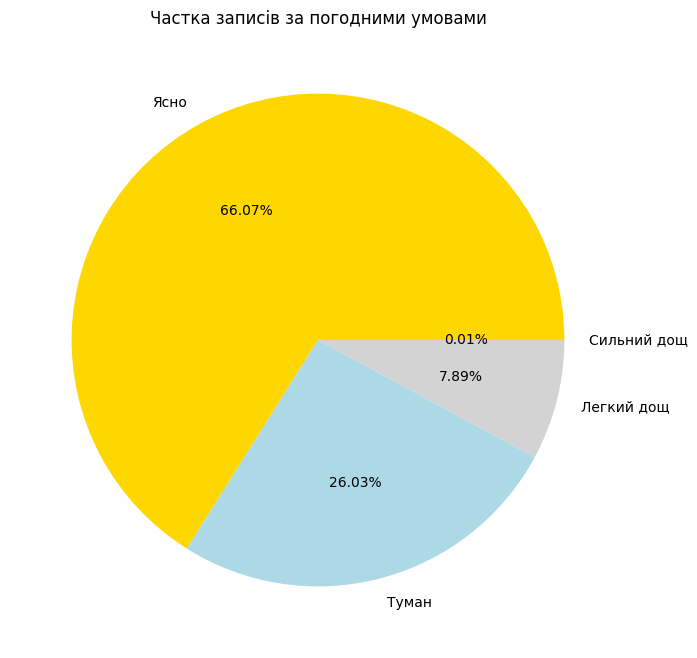

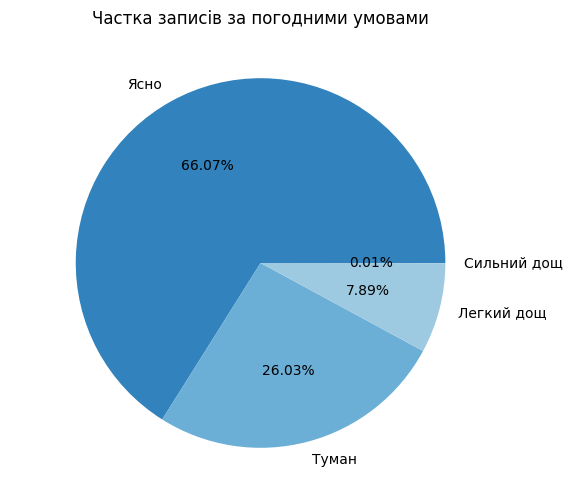

In [10]:
weather_chart= df['weather'].value_counts()
weather_chart.plot.pie(
    figsize=(12, 6),
    autopct='%1.2f%%',
    labels=['Ясно', 'Туман', 'Легкий дощ', 'Сильний дощ'],
    title='Частка записів за погодними умовами',
    ylabel=' ',
    colors=plt.cm.tab20c.colors
);


## Завдання 5: Box Plot для аналізу викидів

**Завдання:**
Створіть коробковий графік (box plot) кількості орендованих велосипедів для кожного типу погоди.

Просунуте доповнення:
- Використайте горизонтальну орієнтацію.
- Позначте погодні умови не числом, а назвою на візуалізації.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. При якій погоді найбільший розкид у кількості оренди?
2. Чи є викиди (outliers) в даних? При якій погоді?
3. При якій погоді медіанне значення оренди найвище?



1.   Найбільший розкид при ясній погоді.
2.   Так, є викиди всюди крім сильного дощу.
3.    Найвища медіана при ясній погоді.



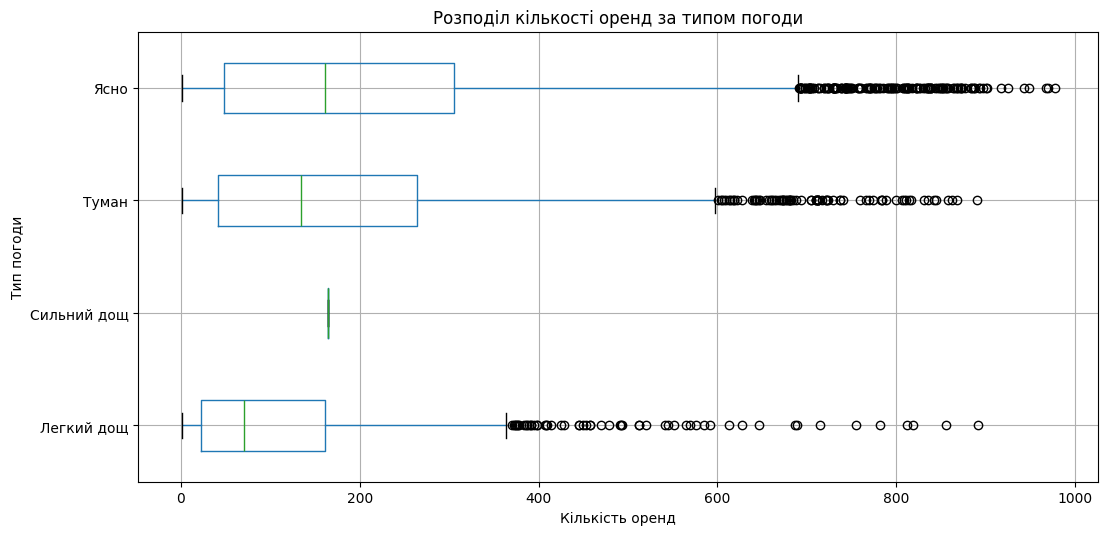

In [11]:
weather_names = {1: 'Ясно', 2: 'Туман', 3: 'Легкий дощ', 4: 'Сильний дощ'}
df['weather_name'] = df['weather'].map(weather_names)

df.boxplot(
    column='count',
    by='weather_name',
    vert=False,
    figsize=(12, 6)
)
plt.title('Розподіл кількості оренд за типом погоди')
plt.suptitle('')
plt.xlabel('Кількість оренд')
plt.ylabel('Тип погоди')
plt.show()

## Завдання 6: Кореляція температури та оренди (Scatter Plot)

**Завдання:**
Побудуйте діаграму розсіювання залежності між температурою (`temp`) та загальною кількістю оренди (`count`). Розфарбуйте точки за сезонами, додайте напівпрозорість (alpha=0.6).

**Увага!** За замовченням буде колір

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
- Чи є зв'язок між температурою та кількістю оренди? Який?

Так, є зв'язок між температоурою і кількістю оренди. З графіку видно що холодні місяці притиснулись до нижньої межи, тобто оренда гірше. А теплі (осінні та літні розтягнулись, присутні викиди аж до 1000). Також можна помітити що в літні місяці (зелені крапки), частота оренд знижується після 30-35 градусів, так як у велику спеку також є певний дискомфорт.

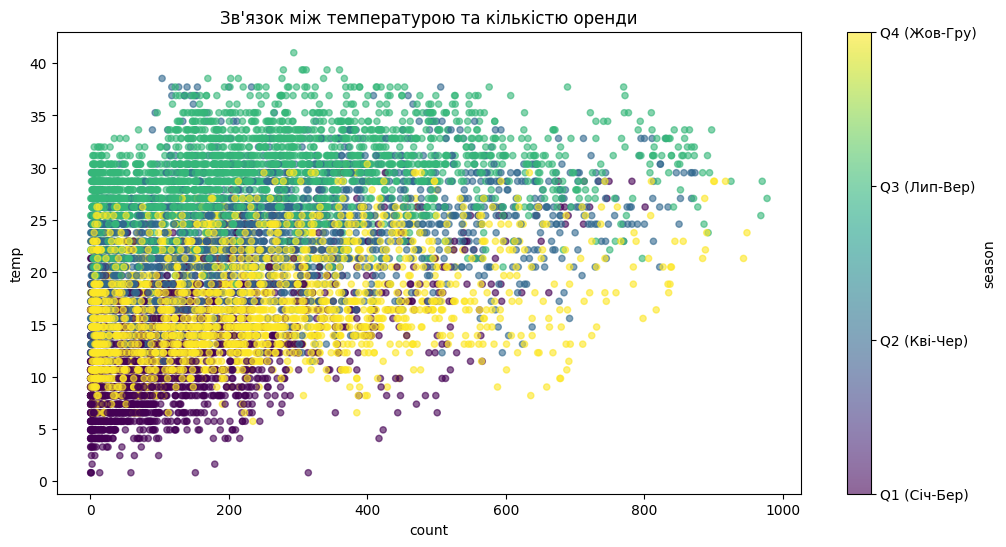

In [12]:
season_names = {1: 'Q1 (Січ-Бер)', 2: 'Q2 (Кві-Чер)', 3: 'Q3 (Лип-Вер)', 4: 'Q4 (Жов-Гру)'}

ax = df.plot.scatter(
    x='count',
    y='temp',
    c='season',
    colormap='viridis',
    alpha=0.6,
    title="Зв'язок між температурою та кількістю оренди",
    figsize=(12, 6)
)

colorbar = ax.collections[0].colorbar
colorbar.set_ticks([1, 2, 3, 4])
colorbar.set_ticklabels([season_names[i] for i in [1, 2, 3, 4]])

plt.show()

## (Опціонально) Завдання 7: Порівняння користувачів (Stacked Bar Chart)

**Завдання:**
Ми хочемо дізнатись як по дням тижня беруть в середньому в оренду велосипеди випадкові і зареєстровані користувачі.

Створіть стовпчасту діаграму з накопиченням (bar з налаштуванням `stacked=True`), яка показує співвідношення випадкових (`casual`) та зареєстрованих (`registered`) користувачів по днях тижня за кількістю взятих ними велосипедів в оренду в середньому. Використайте різні кольори для типів користувачів.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які дні тижня більше оренд від зареєстрованих користувачів?
2. Як ви можете пояснити таку різницю в поведінці користувачів протягом тижня?

1.Зареєстрованих клієнтів більше в робочі дні.
2.Гіпотезую, що в робочі дні орендою користуються клієнти, поїздки яких є цільовими(наприклад на роботу), на вихідних з'являються клієнти із спонтанними бажанням велосипедної прогулянки

/tmp/ipykernel_28856/2652964855.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result = df.groupby(by = 'weekday')[['casual', 'registered']].mean()


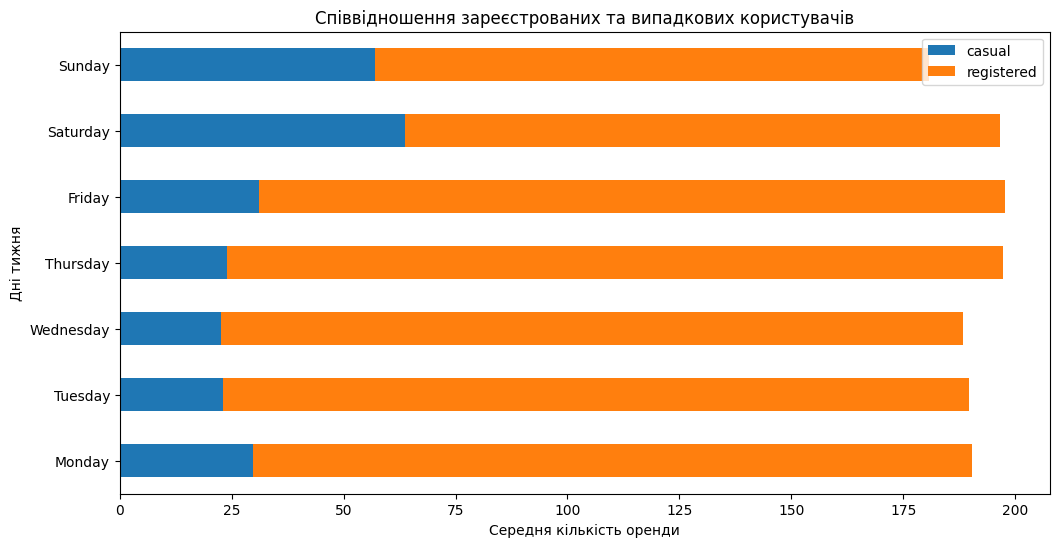

In [18]:

ordered_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['weekday'] = pd.Categorical(df['weekday'], categories= ordered_days, ordered = True )

result = df.groupby(by = 'weekday')[['casual', 'registered']].mean()

result.plot.barh(
    stacked = True,
    title = 'Співвідношення зареєстрованих та випадкових користувачів',
    xlabel = 'Середня кількість оренди',
    ylabel= 'Дні тижня',
    figsize=(12, 6)
)
plt.show()